# Train/Test Split by Date + Model Training

Loads the fully feature-engineered dataset (`opponentvalues.csv`) and trains a Random Forest
classifier using a **chronological** train/test split (never a random split), since several
features (`ELO`, `SEASON_WIN_PCT`, rolling averages, etc.) are cumulative and would leak
future information into the past under a random split.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import joblib

## 1. Load data

In [2]:
path = "../preparation/opponentvalues.csv"
df = pd.read_csv(path)

# Make sure GAME_DATE is a real datetime, not a string
# (string sorting on dates like 'OCT 24, 2018' does NOT sort chronologically)
df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])

print(df.shape)
df.head()

(16578, 74)


,GAME_DATE,GAME_ID,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,MATCHUP,WL,MIN,FGM,...,ELO_DIFF,SEASON_WIN_PCT_DIFF,WIN_STREAK_DIFF,LEAGUE_POSITION_DIFF,ROLL3_PLUS_MINUS_DIFF,ROLL3_FG_PCT_DIFF,ROLL3_PTS_DIFF,ROLL3_REB_DIFF,PREV_PLUSMINUS_DIFF,PREV_PTS_DIFF
0,2019-10-22,21900001,22019,1610612740,NOP,New Orleans Pelicans,NOP @ TOR,L,265,43,...,0.0,NaN,NaN,NaN,-7.0,-0.0415,-5.5,-1.5,NaN,NaN
1,2019-10-22,21900001,22019,1610612761,TOR,Toronto Raptors,TOR vs. NOP,W,265,42,...,0.0,NaN,NaN,NaN,7.0,0.0415,5.5,1.5,NaN,NaN
2,2019-10-22,21900002,22019,1610612746,LAC,LA Clippers,LAC vs. LAL,W,240,42,...,0.0,NaN,NaN,NaN,22.0,0.0810,19.0,10.5,NaN,NaN
3,2019-10-22,21900002,22019,1610612747,LAL,Los Angeles Lakers,LAL @ LAC,L,240,37,...,0.0,NaN,NaN,NaN,-22.0,-0.0810,-19.0,-10.5,NaN,NaN
4,2019-10-23,21900004,22019,1610612765,DET,Detroit Pistons,DET @ IND,W,240,41,...,0.0,NaN,NaN,NaN,-35.0,-0.0810,-17.0,-8.0,NaN,NaN


## 2. Define feature columns

Everything that is an identifier, a raw text/categorical field, a post-game outcome column,
or the target itself is excluded. Adjust `exclude_cols` if your CSV has extra columns
beyond what's listed here.

In [15]:
# Columns that should NEVER be used as model features:
# - identifiers (GAME_ID, TEAM_ID, SEASON_ID, TEAM_ABBREVIATION, TEAM_NAME, OPP, MATCHUP)
# - raw date/text fields
# - the target itself (WIN) and anything that only exists because the game already happened
#   (WL, PTS, PLUS_MINUS, and all other same-game box score stats  --  these describe the
#   outcome of the game we are trying to predict, so including them would be leakage)
exclude_cols = [
    "GAME_DATE", "GAME_ID", "SEASON_ID", "TEAM_ID", "TEAM_ABBREVIATION",
    "TEAM_NAME", "MATCHUP", "WL", "OPP", "VIDEO_AVAILABLE",
    "PLUS_MINUS", # target
    # same-game box score columns (only PREV_/ROLL/DIFF/ELO/etc. engineered versions are safe)
    "MIN", "FGM", "FGA", "FG_PCT", "FG3M", "FG3A", "FG3_PCT",
    "FTM", "FTA", "FT_PCT", "OREB", "DREB", "REB", "AST", "STL",
    "BLK", "TOV", "PF", "PTS", "WIN",
]

feature_cols = [c for c in df.columns if c not in exclude_cols]
target_col = "PLUS_MINUS"

print(f"Using {len(feature_cols)} features:")
print(feature_cols)

Using 43 features:
['HOME', 'PREV_WIN', 'PREV_PTS', 'PREV_PLUSMINUS', 'WIN_STREAK', 'LOSE_STREAK', 'DAYS_REST', 'IS_BACK_TO_BACK', 'SEASON_WIN_PCT', 'ELO', 'LEAGUE_POSITION', 'ROLL3_PTS', 'ROLL3_PLUS_MINUS', 'ROLL3_FG_PCT', 'ROLL3_REB', 'ROLL3_AST', 'ROLL3_TOV', 'OPP_PREV_WIN', 'OPP_PREV_PTS', 'OPP_PREV_PLUSMINUS', 'OPP_WIN_STREAK', 'OPP_LOSE_STREAK', 'OPP_DAYS_REST', 'OPP_IS_BACK_TO_BACK', 'OPP_SEASON_WIN_PCT', 'OPP_ELO', 'OPP_LEAGUE_POSITION', 'OPP_ROLL3_PTS', 'OPP_ROLL3_PLUS_MINUS', 'OPP_ROLL3_FG_PCT', 'OPP_ROLL3_REB', 'OPP_ROLL3_AST', 'OPP_ROLL3_TOV', 'ELO_DIFF', 'SEASON_WIN_PCT_DIFF', 'WIN_STREAK_DIFF', 'LEAGUE_POSITION_DIFF', 'ROLL3_PLUS_MINUS_DIFF', 'ROLL3_FG_PCT_DIFF', 'ROLL3_PTS_DIFF', 'ROLL3_REB_DIFF', 'PREV_PLUSMINUS_DIFF', 'PREV_PTS_DIFF']


## 3. Chronological train/test split

Set `cutoff_date` to whatever season boundary makes sense for your data (train on everything
before it, test on everything from that date onward). Cutting on a season boundary avoids
mixing the cold-start portion of a test season's Elo/win% with an otherwise "warmed up" model.

In [5]:
cutoff_date = "2025-10-01"  # <-- adjust to your desired season boundary

df = df.sort_values("GAME_DATE").reset_index(drop=True)

train_df = df[df["GAME_DATE"] < cutoff_date]
test_df = df[df["GAME_DATE"] >= cutoff_date]

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

print(f"Train: {X_train.shape}, date range {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Test:  {X_test.shape}, date range {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")

Train: (14118, 43), date range 2019-10-22 00:00:00 to 2025-04-13 00:00:00
Test:  (2460, 43), date range 2025-10-21 00:00:00 to 2026-04-12 00:00:00


## 4. Build preprocessing + model pipeline

Early-season games have `NaN` in cumulative features (first game of a season for a team
has no prior Elo/win%/rolling stats), so numeric columns are median-imputed before fitting.

In [6]:
from sklearn.ensemble import RandomForestRegressor

numeric_features = feature_cols  # all remaining features are numeric after exclusions above

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )),
])

## 5. Cross-validate on the training set (chronological folds)

Uses `TimeSeriesSplit` on the training portion only — this never touches the held-out test
set, so it's safe to use for tuning before the final evaluation below.

In [7]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring="neg_mean_absolute_error")
print("Mean CV MAE:", -cv_scores.mean())

Mean CV MAE: 11.105043207253152


## 6. Fit on full training set, evaluate on held-out test set

This is the single number that matters most — performance on games strictly after the
cutoff date, using only information available before each game was played.

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} points")
print(f"RMSE: {rmse:.2f} points")
print(f"R²:   {r2:.3f}")

MAE:  11.49 points
RMSE: 217.01 points
R²:   0.203


In [10]:
from sklearn.metrics import accuracy_score

predicted_win = (y_pred > 0).astype(int)
actual_win = (y_test > 0).astype(int)

derived_accuracy = accuracy_score(actual_win, predicted_win)
print(f"Win/loss accuracy derived from margin regression: {derived_accuracy:.4f}")

Win/loss accuracy derived from margin regression: 0.6756


In [ ]:
def bucket_margin(x):
    if x > 10:
        return "clear_win"
    elif x < -10:
        return "clear_loss"
    else:
        return "close"

predicted_bucket = pd.Series(y_pred).apply(bucket_margin)
actual_bucket = y_test.apply(bucket_margin)

bucket_accuracy = accuracy_score(actual_bucket, predicted_bucket)
print(f"3-class bucket accuracy (derived): {bucket_accuracy:.4f}")

print(classification_report(actual_bucket, predicted_bucket))

3-class bucket accuracy (derived): 0.5317
              precision    recall  f1-score   support

  clear_loss       0.61      0.22      0.33       641
   clear_win       0.61      0.23      0.33       641
       close       0.51      0.87      0.64      1178

    accuracy                           0.53      2460
   macro avg       0.58      0.44      0.43      2460
weighted avg       0.56      0.53      0.48      2460



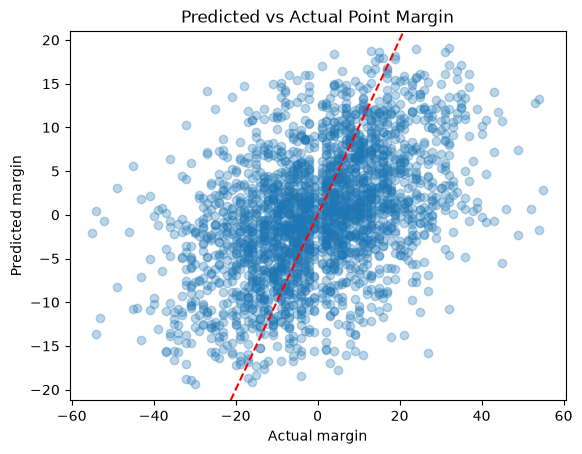

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual margin")
plt.ylabel("Predicted margin")
plt.axline((0, 0), slope=1, color="red", linestyle="--")
plt.title("Predicted vs Actual Point Margin")
plt.show()

## Feature importances

In [14]:
importances = model.named_steps["regressor"].feature_importances_
feature_names = numeric_features  # order matches ColumnTransformer's 'num' block

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

importance_df.head(20)

,Feature,Importance
33,ELO_DIFF,0.176283
34,SEASON_WIN_PCT_DIFF,0.032050
9,ELO,0.030577
25,OPP_ELO,0.029901
31,OPP_ROLL3_AST,0.028947
13,ROLL3_FG_PCT,0.028584
15,ROLL3_AST,0.028464
16,ROLL3_TOV,0.028388
29,OPP_ROLL3_FG_PCT,0.028084
32,OPP_ROLL3_TOV,0.027977
